# Structure in an unlabeled genotype matrix

Eight people were typed at ten SNPs. Their group labels were not used to collect the genotypes. Can the matrix reveal the groups?

At SNP $\ell$, let $x_{\ell i}$ count one allele in person $i$. If person $i$ belongs to group $C_i=k$, a simple model is

$$
x_{\ell i}\mid C_i=k\sim\operatorname{Binomial}(2,p_{\ell k}).
$$

Widely separated SNPs can be independent within a group. The same hidden group affects the allele frequency at many SNPs, so small differences can accumulate across the matrix. Before looking at the labels, we expect people from the same group to have shorter genotype distances and nearby principal-component coordinates.

The matrix below is transcribed from Pritchard Figure 3.3. Its rows are people and its columns are SNPs. In the lecture, $X$ has the opposite orientation, so $G=X^\top$ here.

In [1]:
G <- matrix(c(
  0, 0, 2, 2, 1, 0, 0, 0, 2, 2,
  2, 1, 1, 0, 1, 2, 1, 2, 1, 1,
  1, 2, 0, 1, 0, 2, 2, 1, 0, 0,
  0, 1, 2, 2, 2, 0, 1, 0, 2, 2,
  1, 2, 0, 0, 0, 1, 2, 1, 1, 0,
  1, 0, 2, 1, 2, 0, 0, 1, 1, 2,
  0, 0, 1, 2, 2, 1, 0, 0, 2, 1,
  2, 2, 0, 0, 1, 2, 0, 2, 0, 1
), nrow = 8, byrow = TRUE)

rownames(G) <- paste0("Person ", 1:8)
colnames(G) <- paste0("SNP ", 1:10)
stopifnot(all(G %in% 0:2), nrow(G) == 8, ncol(G) == 10)
G[1:4, 1:5]

,SNP 1,SNP 2,SNP 3,SNP 4,SNP 5
Person 1,0,0,2,2,1
Person 2,2,1,1,0,1
Person 3,1,2,0,1,0
Person 4,0,1,2,2,2


## Compare people across SNPs

The genotype distance below averages the absolute difference in allele count across the ten SNPs, as in Pritchard Figure 3.4. PCA asks a related descriptive question. Which directions account for the largest variation in the centered matrix? Neither method receives the group labels.

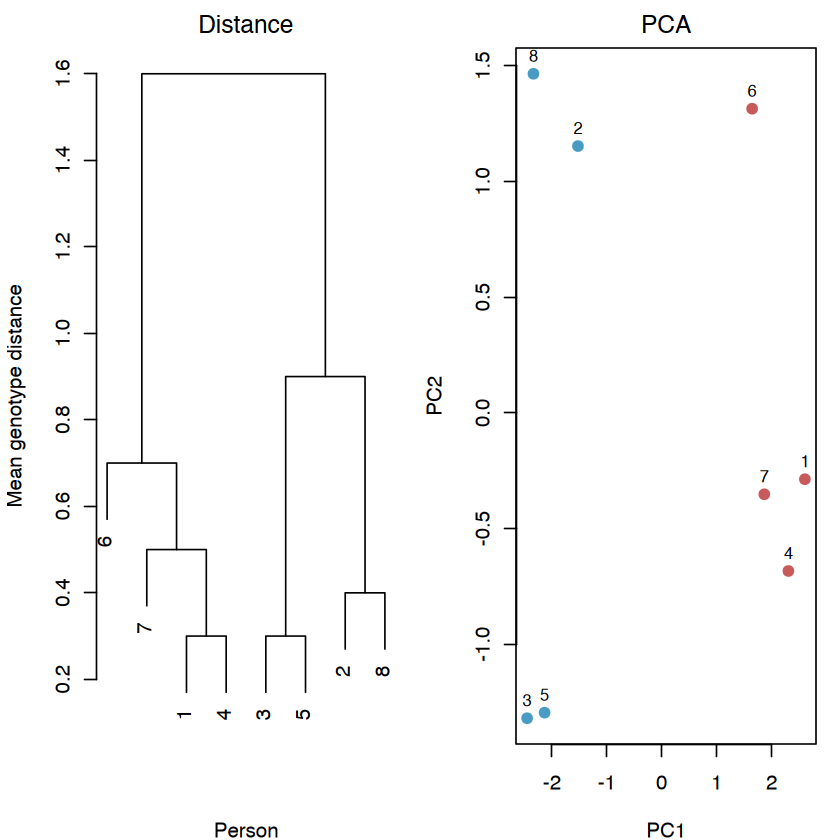

In [2]:
distance <- as.matrix(dist(G, method = "manhattan")) / ncol(G)
pca <- prcomp(G, center = TRUE, scale. = FALSE)

# Figure 3.13 reveals these labels after the unlabeled analysis.
source_group <- c(1, 2, 2, 1, 2, 1, 1, 2)
colors <- c("#C75B5B", "#4A9BC4")

old_par <- par(mfrow = c(1, 2), mar = c(4, 4, 2, 1))
plot(hclust(as.dist(distance)), labels = 1:8, xlab = "Person", sub = "",
     ylab = "Mean genotype distance", main = "Distance")
plot(pca$x[, 1:2], pch = 19, col = colors[source_group],
     xlab = "PC1", ylab = "PC2", main = "PCA")
text(pca$x[, 1:2], labels = 1:8, pos = 3, cex = 0.8)
par(old_par)

within <- outer(source_group, source_group, `==`)
stopifnot(mean(distance[upper.tri(distance) & within]) <
          mean(distance[upper.tri(distance) & !within]))

The colors check the result against Figure 3.13; they were not used to calculate distances or PCs. PC1 separates these eight people, but its sign and scale do not describe ancestry fractions.

## One SNP offers another check

Gorroochurn's two-group example puts equal numbers of people in two populations that each meet Hardy–Weinberg equilibrium (HWE). Their allele frequencies are $0.8$ and $0.2$. Before calculating, we expect fewer pooled heterozygotes than HWE predicts from the pooled frequency. The groups have different frequencies, even though each group meets HWE.

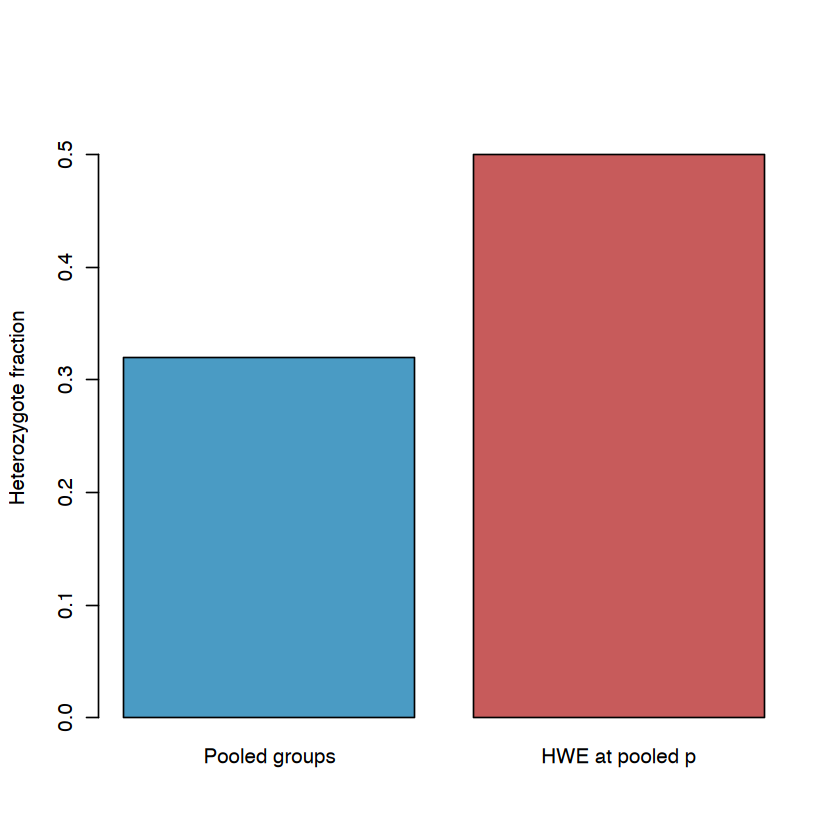

In [3]:
p <- c(0.8, 0.2)
group_weight <- c(0.5, 0.5)
observed_heterozygosity <- sum(group_weight * 2 * p * (1 - p))
pooled_frequency <- sum(group_weight * p)
pooled_hwe_heterozygosity <- 2 * pooled_frequency * (1 - pooled_frequency)

barplot(c(observed_heterozygosity, pooled_hwe_heterozygosity),
        names.arg = c("Pooled groups", "HWE at pooled p"),
        col = c("#4A9BC4", "#C75B5B"), ylim = c(0, 0.55),
        ylab = "Heterozygote fraction")
stopifnot(abs(observed_heterozygosity - 0.32) < 1e-12,
          abs(pooled_hwe_heterozygosity - 0.50) < 1e-12)

The heterozygote deficit shows what pooling can do at one SNP. It does not tell us how many groups there are. Distances and PCA use many SNPs to describe the pattern; the group-specific binomial model explains one way that pattern can arise.

**Sources.** Jonathan Pritchard, *An Owner's Guide to the Human Genome*, [Section 3.1](https://web.stanford.edu/group/pritchardlab/HGbook/ReleaseV1.1/HGBook-V1.1-ch3.1.pdf), Figures 3.3, 3.4, and 3.13. The genotype matrix is transcribed from Figure 3.3; its plots here are new. Prakash Gorroochurn, *Population Genetics Notes*, Section 9.6, supplies the two-population HWE example. The original notes use 200 people; the notebook displays the same calculation as fractions.